In [223]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants

In [224]:
## V_A2 = R * Sigma_p^2 * e^(R/R_d) / R_d * (R_c/arcsec + e^(R/R_d))^-1

#For each bin we have R, need to get a value for sigma_p, R_d and R_c

#Sigma_p is the velocity dispersion for that bin. It is calculated by sigma_p^2 = np.sum(v[i] - mean_v_theta_in_bin)**2 / (len(v_theta_in_bin) - 1)
def get_sigma_p(v):
    mean_v = np.mean(v, axis=0)
    sigma_p_squared = np.sum(((v - mean_v) ** 2) / (len(v)), axis = 0)
    return np.sqrt(sigma_p_squared)

def surface_density_model(R, f0, Rc, Rd):

    return f0 * (Rc + 1) * (Rc + np.exp(R/Rd))**(-1) # Example for illustration




Stellar mass of the galaxy is:  3564107800.0
Dark matter mass of the galaxy is:  144182250000.0
[[-0.97206899  0.03862455  0.23149519]
 [ 0.03862455  0.99924351 -0.00453402]
 [-0.23149519  0.00453402 -0.97282548]]


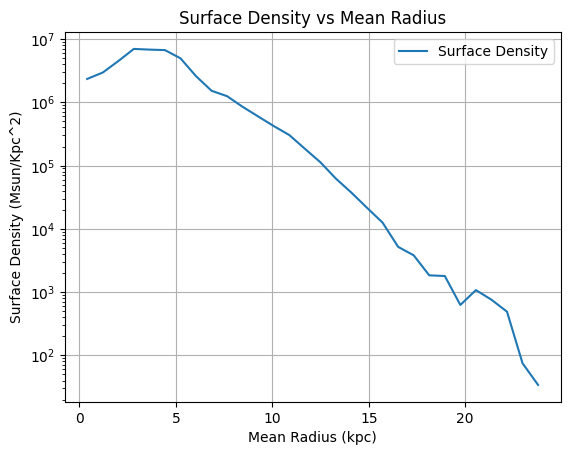

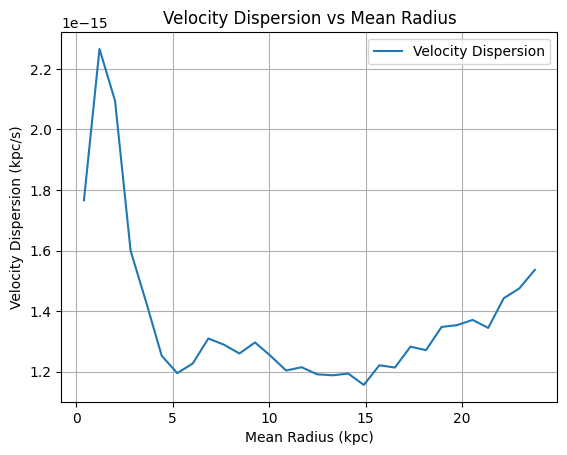

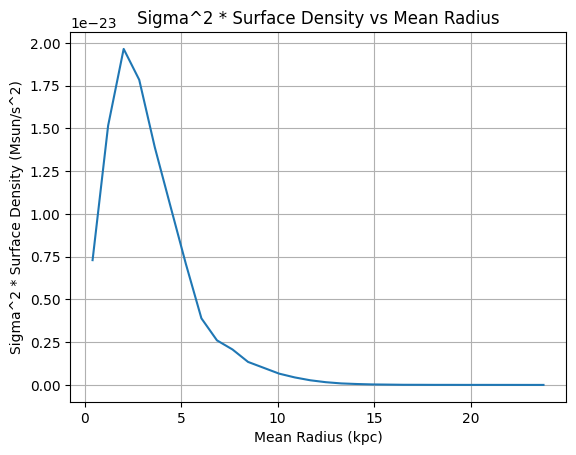

In [225]:
chosen_gals = np.loadtxt('/mnt/users/darnej/MPhys/TNG-50/Chosen_galaxies_TNG.txt')

gal_number = int(chosen_gals[0])  # Change this to the desired galaxy number
from dynamics import load_all_data_TNG

star_data, dm_data, gas_data  = load_all_data_TNG(int(gal_number))

Msun = 1.989e30
kpc_to_m = 3.086e19
kpc_to_km = 3.086e16

Msun_to_H = 1.9885e30/ 1.6726219e-27  # Convert solar mass to hydrogen atoms
kpc_to_cm = 3.086e21  # Convert kpc to cm


if len(star_data['positions']) == 0 or len(star_data['velocities']) == 0:
    print('No data found for galaxy number: ', gal_number)

#Variables with dm infront are from dm and any without are from the baryonic matter

xdata = star_data['positions'][:, 0]
ydata = star_data['positions'][:, 1]
zdata = star_data['positions'][:, 2]

vxdata = star_data['velocities'][:, 0]
vydata = star_data['velocities'][:, 1]
vzdata = star_data['velocities'][:, 2]

massdata = np.array(star_data['masses'])

stellar_mass = np.sum(massdata)
print('Stellar mass of the galaxy is: ', stellar_mass)

if stellar_mass == 0:
    print('No stellar mass found for galaxy number: ', gal_number)

#DM data

dm_xdata = dm_data['positions'][:, 0]
dm_ydata = dm_data['positions'][:, 1]
dm_zdata = dm_data['positions'][:, 2]

dm_vxdata = dm_data['velocities'][:, 0]
dm_vydata = dm_data['velocities'][:, 1]
dm_vzdata = dm_data['velocities'][:, 2]

dm_massdata = np.array(dm_data['masses'])

dm_mass = np.sum(dm_massdata)
print('Dark matter mass of the galaxy is: ', dm_mass)

#Gas data

gas_xdata = gas_data['positions'][:, 0]
gas_ydata = gas_data['positions'][:, 1]
gas_zdata = gas_data['positions'][:, 2]

gas_vxdata = gas_data['velocities'][:, 0]
gas_vydata = gas_data['velocities'][:, 1]
gas_vzdata = gas_data['velocities'][:, 2]

gas_velocities = np.column_stack((gas_vxdata, gas_vydata, gas_vzdata))
gas_positions = np.column_stack((gas_xdata, gas_ydata, gas_zdata))

gas_masses = np.array(gas_data['masses'])

gas_densities = np.array(gas_data['densities'])

H1_frac = np.array(gas_data['H1_frac'])

H1_masses = gas_masses * H1_frac

H1_densities = gas_densities * H1_frac

h1_positions = gas_positions
h1_velocities = gas_velocities
h1_masses = H1_masses
h1_densities = H1_densities


        
Msun = 1.989e30
kpc_to_m = 3.086e19
kpc_to_km = 3.086e16

#Calculate the distance from the centre of the galaxy

rdata = np.sqrt(xdata**2 + ydata**2 + zdata**2)
dm_rdata = np.sqrt(dm_xdata**2 + dm_ydata**2 + dm_zdata**2)

points = np.column_stack((xdata, ydata, zdata))
dm_points = np.column_stack((dm_xdata, dm_ydata, dm_zdata))

#Need to move into center of mass frame of the galaxy

velocities = np.column_stack((vxdata, vydata, vzdata))
dm_velocities = np.column_stack((dm_vxdata, dm_vydata, dm_vzdata))


#Sort the data by distance from the centre of the galaxy
#Create an array called mapping which has the final after its sorted in terms of distance, therefore any other data can be sorted in the same way


from dynamics import create_rotation_matrix

rotation_matrix = create_rotation_matrix(h1_velocities, h1_positions, h1_masses, False)

#Now apply the rotation matrix to the velocity vectors

velocities_rotated = np.dot(rotation_matrix, velocities[:][:].T).T
rotated_points = np.dot(rotation_matrix, points[:][:].T).T

gas_velocities_rotated = np.dot(rotation_matrix, gas_velocities.T).T
gas_positions_rotated = np.dot(rotation_matrix, gas_positions.T).T

h1_velocities_rotated = np.dot(rotation_matrix, h1_velocities.T).T
h1_positions_rotated = np.dot(rotation_matrix, h1_positions.T).T



x = np.log10(h1_densities) + np.log10(Msun_to_H / (kpc_to_cm**3))  # Convert densities to log scale
h1_densities = 10**x  # Convert back to linear scale


mask = h1_densities > 0.01
h1_velocities_rotated = h1_velocities_rotated[mask]
h1_positions_rotated = h1_positions_rotated[mask]
h1_masses = h1_masses[mask]
h1_densities = h1_densities[mask]

#MAYBE DELETE



velocities_rotated = np.append(velocities_rotated, gas_velocities_rotated, axis=0)
rotated_points = np.append(rotated_points, gas_positions_rotated, axis=0)
massdata = np.append(massdata, gas_masses)

rdata = np.append(rdata, np.sqrt(gas_positions[:,0]**2 + gas_positions[:,1]**2 + gas_positions[:,2]**2))


#Now we want to change the velocities from cartesian to cylindrical coordinates
#If r = sqrt(x^2 + y^2) then vr = (x(xdot) + y(ydot))/r
#If tan(theta) = y/x then vtheta = ((ydot)x - y(xdot))/r^2

def cartesian_to_cylindrical_velocity(vx, vy, vz, x, y):
    vr = (x*vx + y*vy)/(x**2 + y**2)**0.5
    vtheta = (x*vy - y*vx)/(x**2 + y**2)**0.5
    vz = vz
    return np.array([vr, vtheta, vz]).T


h1_cylindrical_velocities = cartesian_to_cylindrical_velocity(h1_velocities_rotated[:,0],h1_velocities_rotated[:,1], h1_velocities_rotated[:,2], h1_positions_rotated[:,0], h1_positions_rotated[:,1])

v_theta_h1 = h1_cylindrical_velocities[:,1]
h1_vz = h1_cylindrical_velocities[:,2]


#Now need to convert the points from cartesian to cylindrical coordinates

def cartesian_to_cylindrical_points(x, y, z):
    r = (x**2 + y**2)**0.5
    theta = np.arctan2(y, x)
    z = z
    return np.array([r, theta, z]).T

gas_cylindrical_points = cartesian_to_cylindrical_points(gas_positions_rotated[:,0], gas_positions_rotated[:,1], gas_positions_rotated[:,2])

gas_cylindrical_shells = gas_cylindrical_points[:,0] #r points

h1_cylindrical_points = cartesian_to_cylindrical_points(h1_positions_rotated[:,0], h1_positions_rotated[:,1], h1_positions_rotated[:,2])

h1_cylindrical_shells = h1_cylindrical_points[:,0] #r points


#FINDING ALL ACCELERATIONS AND VELOCITIES

#Want 30 bins between r = 0 and r = 5*Rgas_1/2


dataframe = pd.read_csv('/mnt/users/darnej/MPhys/TNG-50/Galaxy_dataframe_TNG.csv')

gal_numbers = np.array(dataframe['gal_number'])

Rgas_1_2 = dataframe['gas_r_half'][gal_numbers == gal_number].values[0] 

gas_z_half = dataframe['gas_z_half'][gal_numbers == gal_number].values[0]


number_of_bins = 30

bins = np.linspace(0, 5*Rgas_1_2, number_of_bins+1)
bincenters = (bins[1:] + bins[:-1])/2

sigma = []
mean_r = []
surface_density = []
v_obs = []
v_tot = []

for i in range(number_of_bins):

    #FINDING G_OBS

    max_r_for_bin = bins[i+1]
    min_r_for_bin = bins[i]

    mask = (h1_cylindrical_shells > min_r_for_bin) & (h1_cylindrical_shells < max_r_for_bin)

    v_in_bin = h1_cylindrical_velocities[mask]

    mass_in_bin = h1_masses[mask]

    if len(v_in_bin) > 1:

        sigma_in_bin = get_sigma_p(v_in_bin)

        sigma.append(sigma_in_bin)

        surface_dens = np.sum(mass_in_bin) / (np.pi * (max_r_for_bin**2 - min_r_for_bin**2))

        surface_density.append(surface_dens)

        mean_r.append(bincenters[i])

        v_obs.append(np.average(v_in_bin[:, 1], weights = mass_in_bin))  # Average tangential velocity in the bin

        r_in_m = bincenters[i] * kpc_to_m  # Convert bin center to meters
        dm_mask = (dm_rdata < bincenters[i])
        mask = (rdata < bincenters[i])
        x = Msun / r_in_m**2
        x = x * constants.G * (np.sum(massdata[mask]) + np.sum(dm_massdata[dm_mask]))
        g_tot = x

        v_tot.append(np.sqrt(g_tot * r_in_m))

sigma = np.array(sigma) #Units: Kpc/s
surface_density = np.array(surface_density) #Units: Msun/Kpc^2 
mean_r = np.array(mean_r) #Units: Kpc
v_obs = np.array(v_obs) #Units: Kpc/s

plt.plot(mean_r, surface_density, label='Surface Density')
plt.yscale('log')
plt.xlabel('Mean Radius (kpc)')
plt.ylabel('Surface Density (Msun/Kpc^2)')
plt.title('Surface Density vs Mean Radius')
plt.legend()
plt.grid()
plt.show()

sigma_v = np.sqrt(sigma[:,0]**2 + sigma[:,1]**2 + sigma[:,2]**2)

plt.plot(mean_r, sigma_v, label='Velocity Dispersion')
plt.xlabel('Mean Radius (kpc)')
plt.ylabel('Velocity Dispersion (kpc/s)')
plt.title('Velocity Dispersion vs Mean Radius')
plt.legend()
plt.grid()
plt.show()


sigma2_SD = sigma_v**2 * surface_density #Units: Msun/s^2

plt.plot(mean_r, sigma2_SD, label='Sigma^2 * Surface Density')
plt.xlabel('Mean Radius (kpc)')
plt.ylabel('Sigma^2 * Surface Density (Msun/s^2)')
plt.title('Sigma^2 * Surface Density vs Mean Radius')
plt.grid()
plt.show()


In [226]:


# Initial guess for the parameters (f_0, Rc, Rd)

p0 = [sigma2_SD[0], 1, 1] 

try:
    # popt contains the optimal values for the parameters
    # pcov is the covariance matrix
    popt, pcov = curve_fit(surface_density_model, mean_r, sigma2_SD, p0=p0)

    # Extract the fitted parameters
    fitted_f0, fitted_Rc, fitted_Rd = popt
    print(f"Fitted Rc: " + str(fitted_Rc))
    print(f"Fitted Rd: " + str(fitted_Rd))
    print(f"Fitted f0: " + str(fitted_f0))

    # You can then use these fitted_Rc and fitted_Rd values in your V_A calculation.

except RuntimeError as e:
    print(f"Error during curve fitting: {e}")
    print("Try adjusting initial guesses (p0) or checking your data.")



Fitted Rc: 1151.8898669928778
Fitted Rd: 0.7511128032077075
Fitted f0: 1.4990420423281694e-23


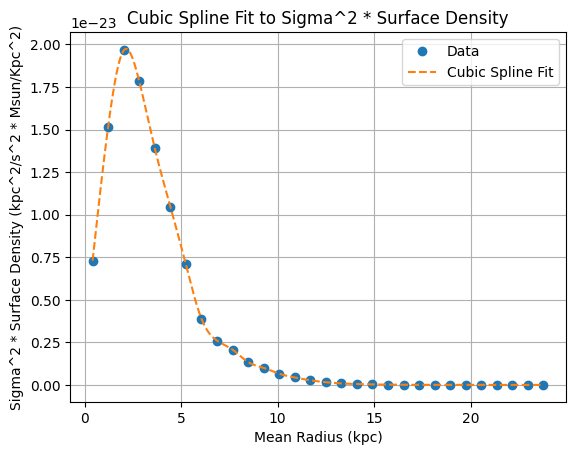

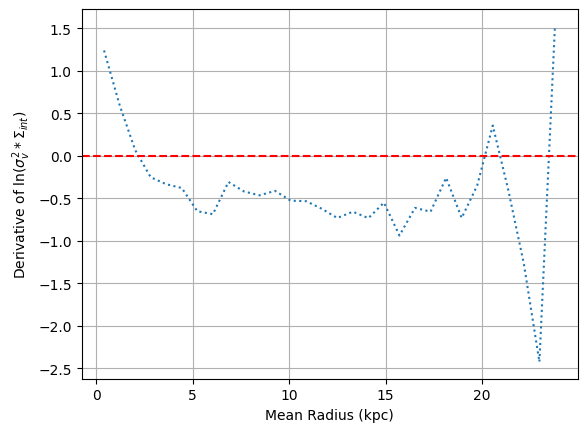

In [227]:
from scipy.interpolate import CubicSpline, interp1d

cs = CubicSpline(mean_r, sigma2_SD, bc_type='natural')


mean_r_fine = np.linspace(mean_r.min(), mean_r.max(), 1000)
y_spline = cs(mean_r_fine)

cs = CubicSpline(mean_r, np.log(sigma2_SD))

y_spline_log = cs(mean_r)
y_der_log = cs.derivative()(mean_r)


plt.plot(mean_r, sigma2_SD, label='Data', marker='o', linestyle='None')
plt.plot(mean_r_fine, y_spline, label='Cubic Spline Fit', linestyle='--')
plt.xlabel('Mean Radius (kpc)')
plt.ylabel('Sigma^2 * Surface Density (kpc^2/s^2 * Msun/Kpc^2)')
plt.title('Cubic Spline Fit to Sigma^2 * Surface Density')
plt.legend()
plt.grid()
plt.show()

#plt.plot(mean_r_fine, y_spline_log, label='Logarithmic Spline Fit', linestyle='--')
plt.plot(mean_r, y_der_log, label='Derivative of $\ln(\sigma_v^2 * \Sigma_{int})$', linestyle=':')
plt.axhline(0, color='red', linestyle='--', label='Zero Line')
plt.xlabel('Mean Radius (kpc)')
plt.ylabel('Derivative of $\ln(\sigma_v^2 * \Sigma_{int})$')
plt.grid()
plt.show()


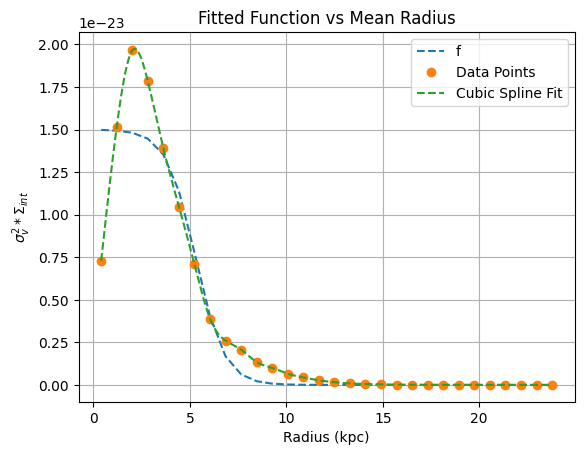

In [228]:
f = fitted_f0 * (fitted_Rc + 1) * (fitted_Rc + np.exp(mean_r / fitted_Rd))**(-1)

plt.plot(mean_r, f, label='f', linestyle='--')
plt.plot(mean_r, sigma2_SD, 'o', label='Data Points')
plt.plot(mean_r_fine, y_spline, label='Cubic Spline Fit', linestyle='--')
plt.xlabel('Radius (kpc)')
plt.ylabel('$\sigma_v^2 * \Sigma_{int}$')
plt.title('Fitted Function vs Mean Radius')
plt.legend()
plt.grid()
plt.show()

In [229]:
VA2_spline = -mean_r * sigma_v**2 * y_der_log

/tmp/ipykernel_971611/3480121221.py:4: RuntimeWarning: invalid value encountered in sqrt
  VA_spline = np.sqrt(VA2_spline)


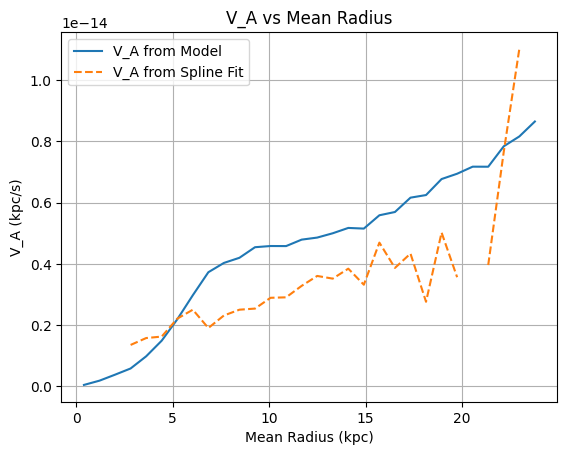

In [230]:
VA2 = mean_r * (sigma_v**2 * np.exp(mean_r / fitted_Rd)) / (fitted_Rd * (fitted_Rc + np.exp(mean_r / fitted_Rd)))
VA = np.sqrt(VA2)

VA_spline = np.sqrt(VA2_spline)

plt.plot(mean_r, VA, label='V_A from Model')
plt.plot(mean_r, VA_spline, label='V_A from Spline Fit', linestyle='--')
plt.xlabel('Mean Radius (kpc)')
plt.ylabel('V_A (kpc/s)')
plt.title('V_A vs Mean Radius')
plt.legend()
plt.grid()
plt.show()

In [231]:

kpc_to_m = 3.086e19  # Convert kpc to meters
VA = VA * kpc_to_m  # Convert to km/s
VA_spline = VA_spline * kpc_to_m  # Convert to km/s
v_obs = v_obs * kpc_to_m  # Convert to km/s

for i in range(len(VA_spline)):
    if np.isnan(VA_spline[i]):
        VA_spline[i] = 0

[ 59178.39746226  92383.00078664 119957.60244653 120127.89435487
 118861.32188995 122393.69539703 127029.83282592 137375.29436361
 148628.43565977 151526.14834537 154384.88704262 159795.98467121
 160168.87945516 159701.40525773 165648.45700061 168040.72628763
 171480.34323399 177266.57115    173868.07342094 184460.42975394
 187215.30730603 198975.81613781 201752.85867957 217158.15348133
 221613.35055246 228751.53797066 227866.10491342 248035.64526441
 259495.40883185 272165.54942029]


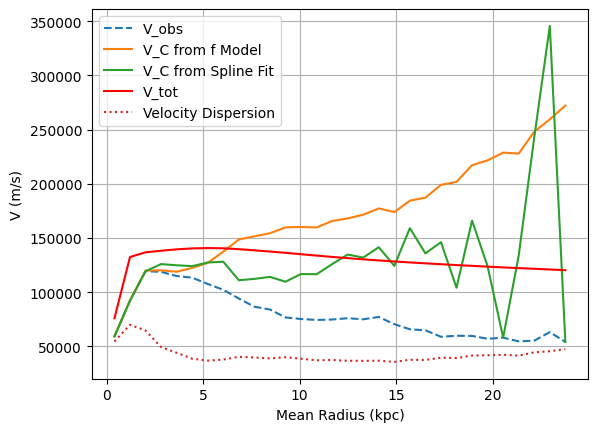

In [232]:
V_C = np.sqrt(v_obs**2 + VA**2)
V_C_spline = np.sqrt(v_obs**2 + VA_spline**2)

print(V_C)

plt.plot(mean_r, v_obs, label='V_obs', linestyle='--')
plt.plot(mean_r, V_C, label='V_C from f Model')
plt.plot(mean_r, V_C_spline, label='V_C from Spline Fit')
plt.plot(mean_r, v_tot, label='V_tot', color = 'red')
plt.plot(mean_r, sigma_v*kpc_to_m, label='Velocity Dispersion', linestyle=':')

plt.xlabel('Mean Radius (kpc)')
plt.ylabel('V (m/s)')
plt.legend()
plt.grid()